# Puzzle

https://thefiddler.substack.com/p/have-you-heard-the-buzz

### This Week’s Fiddler

I recently introduced my children to a game called “Buzz” (also known as "[Fizz buzz](https://en.wikipedia.org/wiki/Fizz_buzz)"), in which players take turns reciting whole numbers in order. However, in one particular variant of the game, anytime a number is a multiple of 7 or at least one of its digits is a 7, the player must say “buzz” instead of that number.

For example, here is how the first 20 turns of the game should proceed: 1, 2, 3, 4, 5, 6, buzz, 8, 9, 10, 11, 12, 13, buzz, 15, 16, buzz, 18, 19, 20.

How many times should “buzz” be said in the first 100 turns of the game (including those mentioned above in the first 20 turns)?

### This Week’s Extra Credit

As we just saw, in the first 20 turns of the game, 15 percent of the numbers were “buzzed.” But as the game proceeds, an increasing frequency of numbers get buzzed.

There is a certain minimum number N such that, for the Nth turn in the game and for every turn thereafter, at least half the numbers up to that point have been buzzed. What is this value of N?



# Solution

Writing some code seems to be the way to go, but to get an idea of what to expect ... 

If we have a k-digit number, the probability of it being a buzz can be calculated as:

$P(buzz) = 1 - P(not buzz) = 1 - (6/7)(9/10)^k$

[If we set that equal to 1/2 and solve](https://www.wolframalpha.com/input?i=solve+%286%2F7%29*%289%2F10%29%5Ex+%3D+1%2F2), we get 5.11574

I interpret that to mean that the solution N should be somewhere in the 6 digit range. But that graph can go up and down, so probably best to go further and make sure it is stably high.

In [3]:
from math import isclose
N_limit = (10**7)

buzz_count = 0
buzz_n = [_ for _ in range(1, N_limit)]
buzz_fracs = []

for n in buzz_n:
    if n % 7 == 0 or '7' in str(n):
        buzz_count += 1
    buzz_frac = buzz_count / n
    buzz_fracs.append(buzz_frac)
    if n == 100:
        print(f"Buzz count at n={n}: {buzz_count}, fraction: {buzz_frac:.6f}\n")
    prev_buzz_frac = buzz_fracs[-2] if len(buzz_fracs) >= 2 else 0
    if (prev_buzz_frac < 0.5 and buzz_frac >= 0.5) or (prev_buzz_frac > 0.5 and buzz_frac <= 0.5) or (prev_buzz_frac == 0.5 and buzz_frac == 0.5):
        print(f"{n}: {prev_buzz_frac:.6f} -> {buzz_frac:.6f} ( {buzz_count} / {n} ) - {'Crossed 0.5' if not isclose(buzz_frac, 0.5, abs_tol=1e-6) else 'Exactly 0.5'}")

Buzz count at n=100: 30, fraction: 0.300000

78732: 0.499994 -> 0.500000 ( 39366 / 78732 ) - Exactly 0.5
84662: 0.500006 -> 0.500000 ( 42331 / 84662 ) - Exactly 0.5
84672: 0.499994 -> 0.500000 ( 42336 / 84672 ) - Exactly 0.5
84690: 0.500006 -> 0.500000 ( 42345 / 84690 ) - Exactly 0.5
84704: 0.499994 -> 0.500000 ( 42352 / 84704 ) - Exactly 0.5
85032: 0.500006 -> 0.500000 ( 42516 / 85032 ) - Exactly 0.5
87480: 0.499994 -> 0.500000 ( 43740 / 87480 ) - Exactly 0.5
89662: 0.500006 -> 0.500000 ( 44831 / 89662 ) - Exactly 0.5
89664: 0.500006 -> 0.500000 ( 44832 / 89664 ) - Exactly 0.5
89672: 0.499994 -> 0.500000 ( 44836 / 89672 ) - Exactly 0.5
89690: 0.500006 -> 0.500000 ( 44845 / 89690 ) - Exactly 0.5
89692: 0.500006 -> 0.500000 ( 44846 / 89692 ) - Exactly 0.5
89702: 0.499994 -> 0.500000 ( 44851 / 89702 ) - Exactly 0.5
90030: 0.500006 -> 0.500000 ( 45015 / 90030 ) - Exactly 0.5
179960: 0.499997 -> 0.500000 ( 89980 / 179960 ) - Exactly 0.5
180066: 0.500003 -> 0.500000 ( 90033 / 180066 ) - Exa

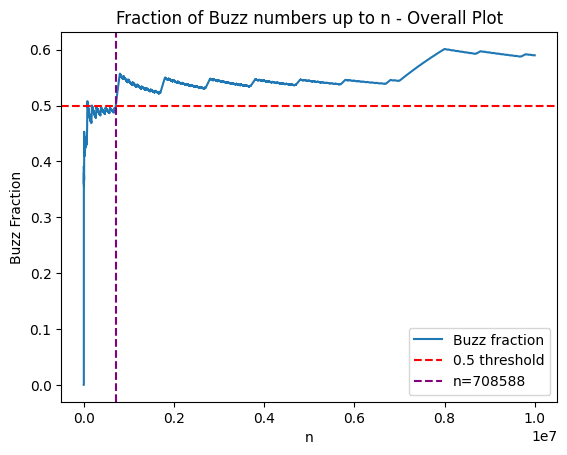

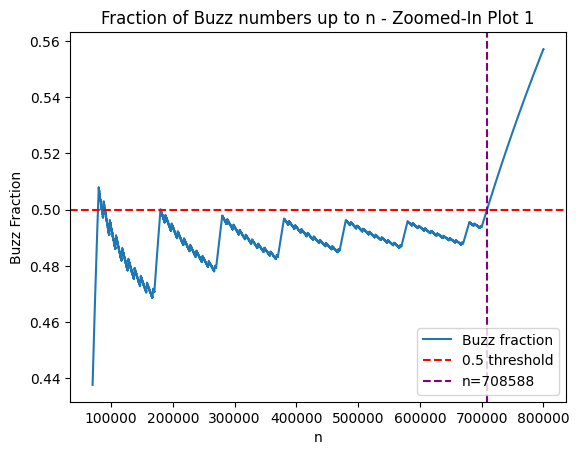

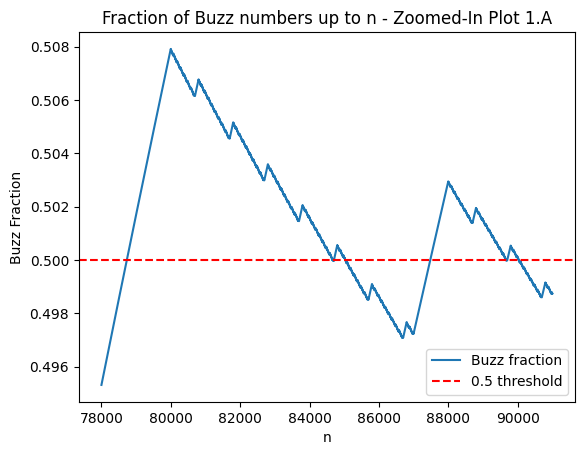

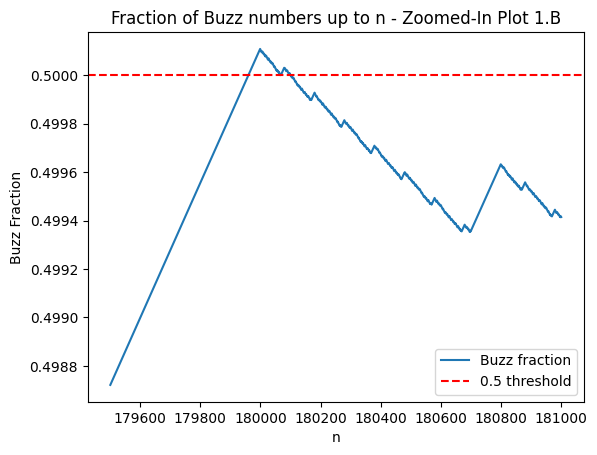

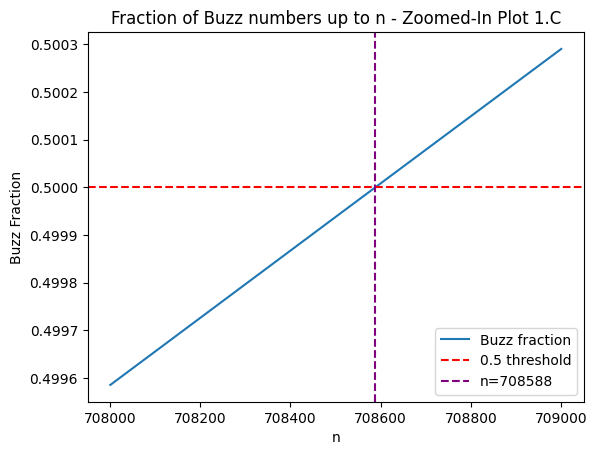

In [4]:
import matplotlib.pyplot as plt

# Overall Plot
plt.plot(buzz_n, buzz_fracs, label='Buzz fraction')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.axvline(708588, color='purple', linestyle='--', label='n=708588')
plt.xlabel('n')
plt.ylabel('Buzz Fraction')
plt.title('Fraction of Buzz numbers up to n - Overall Plot')
plt.legend(loc='lower right')
plt.show()

plt.plot(buzz_n[70000:800000], buzz_fracs[70000:800000], label='Buzz fraction')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.axvline(708588, color='purple', linestyle='--', label='n=708588')
plt.xlabel('n')
plt.ylabel('Buzz Fraction')
plt.title('Fraction of Buzz numbers up to n - Zoomed-In Plot 1')
plt.legend(loc='lower right')
plt.show()

plt.plot(buzz_n[78000:91000], buzz_fracs[78000:91000], label='Buzz fraction')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.xlabel('n')
plt.ylabel('Buzz Fraction')
plt.title('Fraction of Buzz numbers up to n - Zoomed-In Plot 1.A')
plt.legend(loc='lower right')
plt.show()

plt.plot(buzz_n[179500:181000], buzz_fracs[179500:181000], label='Buzz fraction')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.xlabel('n')
plt.ylabel('Buzz Fraction')
plt.title('Fraction of Buzz numbers up to n - Zoomed-In Plot 1.B')
plt.legend(loc='lower right')
plt.show()

plt.plot(buzz_n[708000:709000], buzz_fracs[708000:709000], label='Buzz fraction')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.axvline(708588, color='purple', linestyle='--', label='n=708588')
plt.xlabel('n')
plt.ylabel('Buzz Fraction')
plt.title('Fraction of Buzz numbers up to n - Zoomed-In Plot 1.C')
plt.legend(loc='lower right')
plt.show()


# Conclusion

The Fiddler solution is 30.

The Extra Credit solution is 708588

This graph has a very interesting structure, and it's fun to zoom into the various sections.